In [22]:
#!pip3 install --upgrade tensorflow_hub

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
import numpy as np
import cv2

import PIL.Image as Image
import os

import matplotlib.pylab as plt

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [25]:
# Get this model from tensorflow hub
# IMAGE_SHAPE = (224, 224)

# classifier = tf.keras.Sequential([
#     hub.KerasLayer("https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4", input_shape=IMAGE_SHAPE+(3,))
# ])

In [26]:
import tensorflow_hub as hub
import tensorflow as tf

# This is a TF-Hub "handle" (URL) for MobileNetV2
# Breakdown:
# - mobilenet_v2      : model architecture
# - 035               : width multiplier = small & fast model
# - 224               : trained on 224x224 images
# - classification    : includes final softmax layer for ImageNet
# - /5                : version number
model_handle = "https://tfhub.dev/google/imagenet/mobilenet_v2_035_224/classification/5"

#Load the pretrained model
# ----------------------------------------------------------

# hub.KerasLayer loads the pretrained model as a reusable Keras layer.
# This gives us a fully trained ImageNet classifier.
# No training required — we can directly pass 224x224x3 images to it.
model = hub.KerasLayer(model_handle)



In [27]:
# import tensorflow_hub as hub
# m = tf.keras.Sequential([
#     hub.KerasLayer("https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/035-224-classification/2")
# ])
# m.build([None, 224, 224, 3])  # Batch input shape.


In [28]:
# Create a Sequential model
# We are using Lambda layer to wrap a TF-Hub pretrained model
from tensorflow.keras.layers import Lambda
m = tf.keras.Sequential([

    # Lambda allows custom operations inside the layer.
    # Here, we load a MobileNetV2 pretrained model from Kaggle TFHub.
    # The model accepts images of size 224x224x3.
    Lambda(lambda x: hub.KerasLayer(
        "https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/035-224-classification/2"
    )(x))
])

# Build the model by defining the expected input shape
# None = batch size (variable)
# 224,224,3 = image height, width, channels
m.build([None, 224, 224, 3])

# Print model summary to verify layer structure (optional)

In [29]:
m.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 1001)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
tf.keras.utils.get_file(fname='ImageNetLabels.txt', # Changed fname to just the filename
                        origin='https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt',
                        cache_dir='/content/')

'/content/datasets/ImageNetLabels.txt'

In [31]:
with open("/content/datasets/ImageNetLabels.txt", "r") as f:
    image_labels = f.read().splitlines()

In [32]:
print(image_labels)

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned viper', '

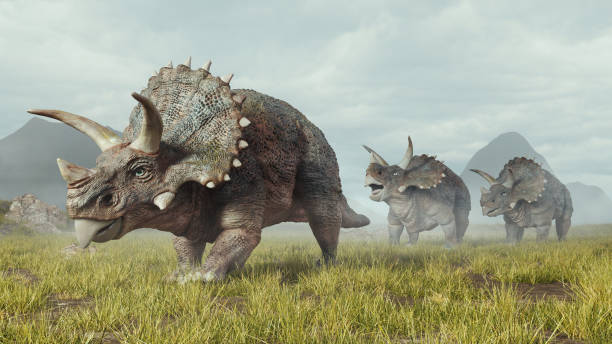

In [33]:
import cv2
from google.colab.patches import cv2_imshow
mypic = cv2.imread("/content/triceratops.jpg")
cv2_imshow(mypic)

In [34]:
# Print the original shape of the image
print(mypic.shape)

# ------------------------------------------------------------
# 1. Resize the image → MobilenetV2 expects 224x224x3 input
# ------------------------------------------------------------
resized_pic = cv2.resize(mypic, (224, 224))
print(resized_pic.shape)        # Should print (224, 224, 3)

# ------------------------------------------------------------
# 2. Normalize pixel values → converts [0,255] to [0,1]
# ------------------------------------------------------------
resized_pic = resized_pic / 255.0

# ------------------------------------------------------------
# 3. Create a batch → Model expects batch dimension (N, 224, 224, 3)
# Here we only have ONE image → so batch size = 1
# ------------------------------------------------------------
batch = resized_pic.reshape(1, 224, 224, 3)

# ------------------------------------------------------------
# 4. Make prediction using the loaded model `m`
# Prediction output shape → (1, 1001) for ImageNet
# ------------------------------------------------------------
output = m.predict(batch)

# ------------------------------------------------------------
# 5. Get index of class with highest probability
# ------------------------------------------------------------
output_ind = np.argmax(output)

# ------------------------------------------------------------
# 6. Fetch the label name using the index from your labels list
# ------------------------------------------------------------
predicted_label = image_labels[output_ind]
print("Predicted Label:", predicted_label)


(344, 612, 3)
(224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
Predicted Label: triceratops


In [35]:
image_labels[np.argmax(m.predict(batch))]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


'triceratops'

In [36]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(fname='flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

In [37]:
data_dir = "/content/datasets/flower_photos/flower_photos"

In [38]:
type(data_dir)

str

In [39]:
# Import pathlib to work with filesystem paths in an easy, OS-independent way
import pathlib

# 'data_dir' at this point is most likely a STRING returned by:
# tf.keras.utils.get_file(..., untar=True)
# Example: data_dir = "./flower_photos"
# We now convert this string into a proper Path object.

data_dir = pathlib.Path(data_dir)

# Print the type of data_dir to verify it is now a pathlib Path object.
# This will show: <class 'pathlib.PosixPath'>
type(data_dir)


pathlib.PosixPath

In [40]:
data_dir.glob("*") ## gives generator object

<generator object Path.glob at 0x7a64c0854590>

In [41]:
list(data_dir.glob("*"))

[PosixPath('/content/datasets/flower_photos/flower_photos/tulips'),
 PosixPath('/content/datasets/flower_photos/flower_photos/sunflowers'),
 PosixPath('/content/datasets/flower_photos/flower_photos/daisy'),
 PosixPath('/content/datasets/flower_photos/flower_photos/LICENSE.txt'),
 PosixPath('/content/datasets/flower_photos/flower_photos/roses'),
 PosixPath('/content/datasets/flower_photos/flower_photos/dandelion')]

In [42]:
list(data_dir.glob("tulips/*"))

[PosixPath('/content/datasets/flower_photos/flower_photos/tulips/8554190977_37ac747799_m.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/tulips/12916135413_dafcf3089e_n.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/tulips/2436998042_4906ea07af.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/tulips/13999402743_f563f6b685_n.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/tulips/15275478257_fbd5850708_n.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/tulips/14235021006_dd001ea8ed_n.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/tulips/14122029097_3e3285ca5c_n.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/tulips/8713391394_4b679ea1e3_n.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/tulips/2232289392_9a79a0c5cb_n.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/tulips/130685245_dcdd23836f_m.jpg'),
 PosixPath('/content/datasets/flower_p

In [43]:
# Get all image paths inside the 'roses' folder
rose_paths = list((data_dir / "roses").glob("*"))
rose_paths[:5]


[PosixPath('/content/datasets/flower_photos/flower_photos/roses/14221192676_eb8c89a7d6_n.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/roses/1562198683_8cd8cb5876_n.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/roses/17449165090_dfb27af360_n.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/roses/475947979_554062a608_m.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/roses/6570546331_ffb9dab0bf_n.jpg')]

In [44]:
len(list(data_dir.glob("roses/*")))

641

In [45]:
print(list(data_dir.glob("roses/*")))

[PosixPath('/content/datasets/flower_photos/flower_photos/roses/14221192676_eb8c89a7d6_n.jpg'), PosixPath('/content/datasets/flower_photos/flower_photos/roses/1562198683_8cd8cb5876_n.jpg'), PosixPath('/content/datasets/flower_photos/flower_photos/roses/17449165090_dfb27af360_n.jpg'), PosixPath('/content/datasets/flower_photos/flower_photos/roses/475947979_554062a608_m.jpg'), PosixPath('/content/datasets/flower_photos/flower_photos/roses/6570546331_ffb9dab0bf_n.jpg'), PosixPath('/content/datasets/flower_photos/flower_photos/roses/13929462317_96342a9a44.jpg'), PosixPath('/content/datasets/flower_photos/flower_photos/roses/14494590921_3bb1dc7b88_n.jpg'), PosixPath('/content/datasets/flower_photos/flower_photos/roses/5156037859_1673720a11_m.jpg'), PosixPath('/content/datasets/flower_photos/flower_photos/roses/5990626258_697f007308_n.jpg'), PosixPath('/content/datasets/flower_photos/flower_photos/roses/4764674741_82b8f93359_n.jpg'), PosixPath('/content/datasets/flower_photos/flower_photos/r

In [46]:
list(data_dir.glob("roses/*"))[1]

PosixPath('/content/datasets/flower_photos/flower_photos/roses/1562198683_8cd8cb5876_n.jpg')

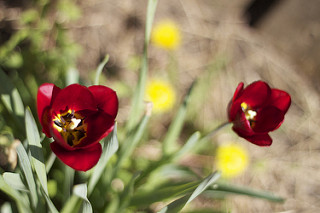

In [47]:
from google.colab.patches import cv2_imshow
myimg = cv2_imshow(cv2.imread(list(data_dir.glob("tulips/*"))[10]))

In [48]:
print(len(list(data_dir.glob("roses/*"))))
print(len(list(data_dir.glob("daisy/*"))))
print(len(list(data_dir.glob("dandelion/*"))))
print(len(list(data_dir.glob("sunflowers/*"))))
print(len(list(data_dir.glob("tulips/*"))))

641
633
898
699
799


In [49]:
641 + 633+898+699+799

3670

In [50]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [51]:
X, y = [], [] # empty list

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(image)
        resized_img = cv2.resize(img,(224,224))
        resized_img = resized_img.astype("float32")/255
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [52]:
len(X)

3670

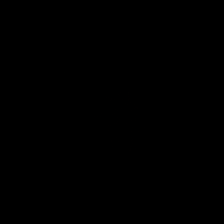

In [60]:
from google.colab.patches import cv2_imshow
cv2_imshow(X[34])

In [54]:
y[34]

0

In [55]:
X = np.array(X)
y = np.array(y)

In [56]:
X.shape

(3670, 224, 224, 3)

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.1 ,stratify=y ,random_state=0)

In [58]:
# feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

# pretrained_model_without_top_layer = hub.KerasLayer(
#     feature_extractor_model, input_shape=(224, 224, 3), trainable=False)
# pretrained_model_without_top_layer

In [62]:
# import tensorflow_hub as hub
# num_classes = 5
# m = tf.keras.Sequential([
#     hub.KerasLayer("https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/035-224-feature-vector/2",
#                    trainable=False),  # Can be True, see below.
#     tf.keras.layers.Dense(num_classes, activation='softmax')
# ])
# m.build([None, 224, 224, 3])  # Batch input shape.


In [63]:
model = tf.keras.Sequential([
  Lambda(lambda x : hub.KerasLayer("https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/035-224-feature-vector/2")(x)),
  keras.layers.Flatten(),
  keras.layers.Dense(200, activation='relu'),
  keras.layers.Dense(5,activation='softmax')
])
model.build([None,224,224,3])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 200)            │       256,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,205 (1004.71 KB)

 Trainable params: 257,205 (1004.71 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
model.compile(
  optimizer="adam",
  loss=tf.keras.losses.SparseCategoricalCrossentropy(),
  metrics=['acc'])

model.fit(X_train,y_train, epochs=5)

Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 34s 115ms/step - acc: 0.6909 - loss: 0.8276
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - acc: 0.8912 - loss: 0.3036
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - acc: 0.9382 - loss: 0.1943
Epoch 4/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.9661 - loss: 0.1216
Epoch 5/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - acc: 0.9788 - loss: 0.0860


In [ ]:
# m.compile(
#   optimizer="adam",
#   loss=tf.keras.losses.SparseCategoricalCrossentropy(),
#   metrics=['acc'])

# m.fit(X_train, y_train, epochs=5)

In [68]:
demopic = cv2.imread("/content/datasets/flower_photos/flower_photos/roses/12202373204_34fb07205b.jpg")
demopic = cv2.resize(demopic,(224,224)) # resizing
demopic = demopic.astype("float32")/255 # rescaling from 0-255 to 0-1
batch = demopic.reshape(1,224,224,3) # reshape --> (no. of images, rows, cols, channels)
output = model.predict(batch)
print(output)# print probability values for all categories
print(output.max()) # print max probability value
print(np.argmax(output)) # fetching index of max probability value getting from o/p layer neuron (getting this in the form of vectors of probability values for all categories)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[9.9999094e-01 5.8568969e-07 1.2437681e-08 8.5945189e-09 8.5198617e-06]]
0.99999094
0


# Building complete code again